# NTSB GA Accident Risk — Data Prep

Month 3 project. Goal: predict whether a general aviation accident is fatal, from the weather conditions recorded at the time of the accident.

Data source: NTSB's full aviation accident database (`avall.mdb`, 1982-present), downloaded from [data.ntsb.gov/avdata](https://data.ntsb.gov/avdata). The `events` table already includes weather observations captured by investigators (ceiling, visibility, wind, temperature, VMC/IMC) for each accident, so no external METAR join is needed for a first pass.

`.mdb` isn't readable by pandas directly, so the `events` table was exported to CSV with `mdbtools`:
```bash
mdb-export avall.mdb events > events.csv
```

In [184]:
import pandas as pd

df = pd.read_csv('events.csv')
print(df.shape)
df.head()

(30804, 73)


/var/folders/fl/d9pyllks1vbgx9hrb83g14_80000gn/T/ipykernel_91414/1909467885.py:3: DtypeWarning: Columns (0: ev_id, 1: ev_site_zipcode, 2: wx_obs_tmzn, 3: metar) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('events.csv')


,ev_id,ntsb_no,ev_type,ev_date,ev_dow,ev_time,ev_tmzn,ev_city,ev_state,ev_country,...,ntsb_notf_from,ntsb_notf_date,ntsb_notf_tm,fiche_number,lchg_date,lchg_userid,wx_cond_basic,faa_dist_office,dec_latitude,dec_longitude
0,20080211X00175,DFW08RA039,ACC,01/10/08 00:00:00,Th,1907.0,UTC,Pitt Meadows,NaN,CA,...,NaN,NaN,NaN,NaN,09/23/25 18:50:18,dobn,NaN,NaN,49.216634,-122.683870
1,20080107X00026,SEA08LA057,ACC,01/01/08 00:00:00,Tu,2230.0,UTC,Sonoma,CA,USA,...,NaN,NaN,NaN,NaN,09/25/20 18:05:31,NaN,VMC,NaN,38.223888,-122.449722
2,20080109X00036,DFW08CA054,ACC,01/01/08 00:00:00,Tu,2200.0,UTC,Arcola,TX,USA,...,NaN,NaN,NaN,NaN,09/25/20 18:05:31,NaN,VMC,NaN,29.506111,-95.476669
3,20080107X00027,DFW08LA055,ACC,01/03/08 00:00:00,Th,825.0,UTC,Oklahoma City,OK,USA,...,NaN,NaN,NaN,NaN,09/25/20 18:04:02,NaN,VMC,NaN,35.533611,-97.641387
4,20080115X00051,DEN08CA047,ACC,01/02/08 00:00:00,We,2230.0,UTC,Loveland,CO,USA,...,NaN,NaN,NaN,NaN,09/25/20 18:06:16,NaN,VMC,NaN,40.451667,-105.001113


## Columns available

Full column reference — event identity/location, weather at time of accident, injury outcome, and admin metadata. See the [NTSB data dictionary](https://www.ntsb.gov/Pages/AviationDownloadDataDictionary.aspx) for field meanings.

In [185]:
df.columns

Index(['ev_id', 'ntsb_no', 'ev_type', 'ev_date', 'ev_dow', 'ev_time',
       'ev_tmzn', 'ev_city', 'ev_state', 'ev_country', 'ev_site_zipcode',
       'ev_year', 'ev_month', 'mid_air', 'on_ground_collision', 'latitude',
       'longitude', 'latlong_acq', 'apt_name', 'ev_nr_apt_id', 'ev_nr_apt_loc',
       'apt_dist', 'apt_dir', 'apt_elev', 'wx_brief_comp', 'wx_src_iic',
       'wx_obs_time', 'wx_obs_dir', 'wx_obs_fac_id', 'wx_obs_elev',
       'wx_obs_dist', 'wx_obs_tmzn', 'light_cond', 'sky_cond_nonceil',
       'sky_nonceil_ht', 'sky_ceil_ht', 'sky_cond_ceil', 'vis_rvr', 'vis_rvv',
       'vis_sm', 'wx_temp', 'wx_dew_pt', 'wind_dir_deg', 'wind_dir_ind',
       'wind_vel_kts', 'wind_vel_ind', 'gust_ind', 'gust_kts', 'altimeter',
       'wx_dens_alt', 'wx_int_precip', 'metar', 'ev_highest_injury',
       'inj_f_grnd', 'inj_m_grnd', 'inj_s_grnd', 'inj_tot_f', 'inj_tot_m',
       'inj_tot_n', 'inj_tot_s', 'inj_tot_t', 'invest_agy', 'ntsb_docket',
       'ntsb_notf_from', 'ntsb_notf_date'

## Target distribution

`ev_highest_injury` is the natural target candidate — check class balance first. Fatal isn't rare here: ~21.5% of categorized accidents are fatal.

In [186]:
df['ev_highest_injury'].value_counts()

ev_highest_injury
NONE    15618
FATL     6300
MINR     4097
SERS     3358
Name: count, dtype: int64

## Candidate weather features + missingness

Weather columns that plausibly matter for risk: ceiling, visibility, wind, gust, temperature, and the basic VMC/IMC flag. Checking null counts alongside the two injury-target candidates. `metar` (raw text) turns out to be missing 80% of the time — too sparse to use as a model input.

In [187]:
indp_features = df[['sky_ceil_ht','vis_sm','wind_vel_kts','gust_kts','wx_temp','wx_cond_basic','metar']]
dep_feature = df[['ev_highest_injury','inj_tot_f']]

indp_features.isna().sum()

sky_ceil_ht        144
vis_sm            6816
wind_vel_kts     10972
gust_kts             8
wx_temp            144
wx_cond_basic     5231
metar            24804
dtype: int64

In [188]:
dep_feature.isna().sum()

ev_highest_injury    1431
inj_tot_f               0
dtype: int64

## Sanity check: is `gust_kts` really 0, or is 0 standing in for missing?

Only 8 nulls out of ~30,800 rows is suspicious — physically, most accidents shouldn't have gust conditions at all, so we'd expect *more* missing, not less. Checking the value distribution: 0 is overwhelmingly the most common value (26,870 rows), which confirms it's a legitimate "no gust reported" reading, not a missing-data placeholder.

In [189]:
df['gust_kts'].value_counts().head()

gust_kts
0.0     26870
15.0      358
20.0      336
18.0      330
16.0      318
Name: count, dtype: int64

## Sanity check: is `inj_tot_f` reliable as a target?

Same question as `gust_kts` — could 0 secretly mean "unknown" rather than "no fatalities"? `inj_tot_f` has zero missing values. Unlike a weather observation (which might genuinely not be recorded), fatality count is a mandatory investigation outcome — it's always determined before a case closes. Still worth verifying with data rather than assuming.

In [190]:
df['inj_tot_f'].value_counts().head()

inj_tot_f
0    24547
1     3260
2     1737
3      513
4      344
Name: count, dtype: int64

Cross-check against `ev_highest_injury`: any accident marked `FATL` should have `inj_tot_f > 0`. If not, something's off.

In [191]:
df[(df['ev_highest_injury'] == 'FATL') & (df['inj_tot_f'] == 0)].shape[0]

43

43 mismatches out of 6,300 FATL accidents (0.68%) — small, and a different failure pattern than `gust_kts`. Likely explanation: `inj_tot_f` counts *occupant* fatalities only, while a fatality on the ground (`inj_f_grnd`) would still correctly mark the event `FATL` overall. Confirm:

In [192]:
rest_table = df[(df['ev_highest_injury'] == 'FATL') & (df['inj_tot_f'] == 0)]
rest_table['inj_f_grnd'].value_counts()

inj_f_grnd
1.0    34
2.0     6
3.0     2
6.0     1
Name: count, dtype: int64

All 43 mismatches have `inj_f_grnd > 0` — confirmed. These are legitimate ground-fatality cases, not a data quality problem. `inj_tot_f` is trustworthy.

Also check the reverse direction — no accident marked `NONE` should have a recorded fatality:

In [193]:
df[(df['ev_highest_injury'] == 'NONE') & (df['inj_tot_f'] > 0) ].shape[0]

0

## Target definition

`is_fatal = (inj_tot_f > 0) | (ev_highest_injury == 'FATL')` will be the binary target.

Separately, fill the 1,431 null `ev_highest_injury` rows so the full 4-class severity label (Fatal/Serious/Minor/None) is usable later too. This fill is only valid if the injury-count columns it depends on are themselves fully populated — check `inj_tot_s` and `inj_tot_m` before trusting it.

In [194]:
df['inj_tot_s'].isna().sum()

np.int64(0)

In [195]:
df['inj_tot_m'].isna().sum()

np.int64(0)

Both fully populated — safe to fill nulls using the same fatal > serious > minor > none priority NTSB itself would use to derive this field.

In [196]:
def fill_injury(row):
    if row['inj_tot_f'] > 0: return 'FATL'
    if row['inj_tot_s'] > 0: return 'SERS'
    if row['inj_tot_m'] > 0: return 'MINR'
    return 'NONE'

df['ev_highest_injury'] = df['ev_highest_injury'].fillna(df.apply(fill_injury, axis=1))


In [197]:
df['ev_highest_injury'].isna().sum()

np.int64(0)

## Next

Build the normalized feature tensor (weather columns + one-hot `wx_cond_basic`) and the `is_fatal` target, following the fast.ai lesson 4 linear-model / neural-net-from-scratch pattern.

## Clean features for modeling

Dropping `metar` (80% missing, established earlier) and building the final feature set: ceiling, visibility, wind, gust, temperature, and VMC/IMC.

In [198]:
indp_features = df[['sky_ceil_ht','vis_sm','wind_vel_kts','gust_kts','wx_temp','wx_cond_basic']]
indp_features.shape

(30804, 6)

## Fill missing values

Using the mode per column rather than the mean. For `wx_cond_basic` (categorical) mode is the only sensible choice. For the numeric weather columns, checking the actual mode values shows they line up with real aviation-weather reporting conventions rather than being arbitrary: `vis_sm` mode is 10.0 (visibility is commonly reported/capped at "10SM"), `sky_ceil_ht` and `gust_kts` mode is 0.0 (clear skies / no gust, both legitimate common conditions, consistent with the `gust_kts` check earlier).

In [199]:
modes = indp_features.mode().iloc[0]
indp_features = indp_features.fillna(modes)
indp_features.isna().sum()

sky_ceil_ht      0
vis_sm           0
wind_vel_kts     0
gust_kts         0
wx_temp          0
wx_cond_basic    0
dtype: int64

## Outlier check: `vis_sm`

Raw histogram first, to see what's actually there:

<Axes: >

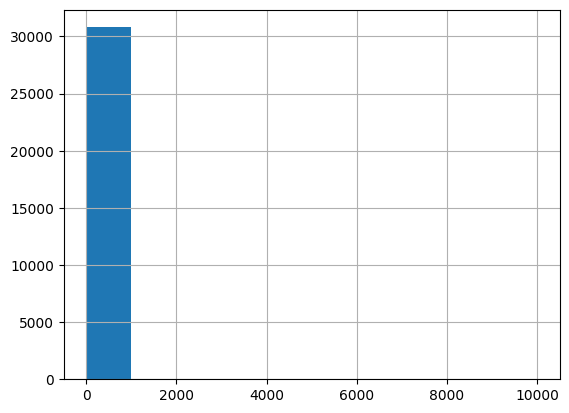

In [200]:
indp_features['vis_sm'].hist()

That's broken — a handful of sentinel values (`9999`, `5000`, `4500`, `100`) stretch the x-axis so far that the real distribution (which lives between 0 and 15) collapses into a single bar near zero. Default `.hist()` splits the *full* min-max range into 10 bins, so a few bad values dictate the whole plot. Zooming into the plausible range reveals the actual shape:

<Axes: >

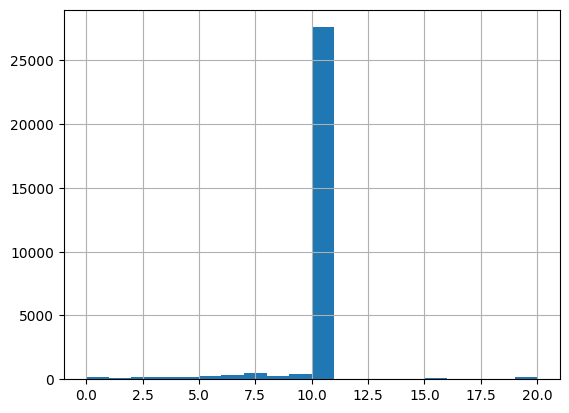

In [201]:
indp_features['vis_sm'].hist(range=(0,20), bins=20)

Confirms the spike at 10sm (the reporting convention for "visibility ≥10sm") and a real spread below it. Boxplot makes the outliers explicit as individual points:

<Axes: >

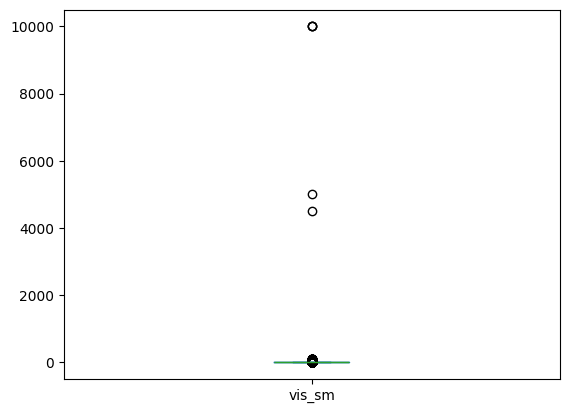

In [202]:
indp_features['vis_sm'].plot(kind='box')

Cutoff: **15 statute miles**. Real surface visibility essentially never exceeds this; everything above it is a sentinel/data-entry artifact, not a genuine reading.

<Axes: >

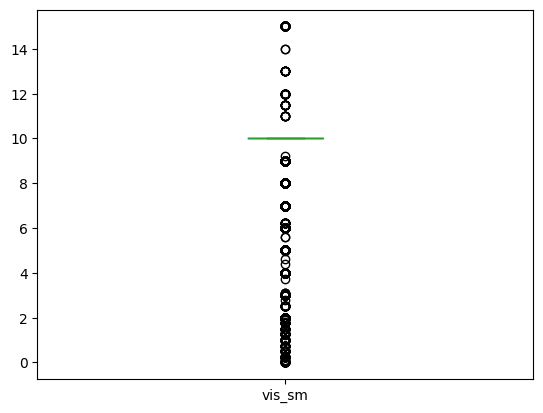

In [203]:
indp_features = indp_features[indp_features['vis_sm'] <= 15]
indp_features['vis_sm'].plot(kind='box')

## Outlier check: `sky_ceil_ht`

Ceiling in feet. One clear impossible value here (a 260,000ft "ceiling" — physically nonsensical):

<Axes: >

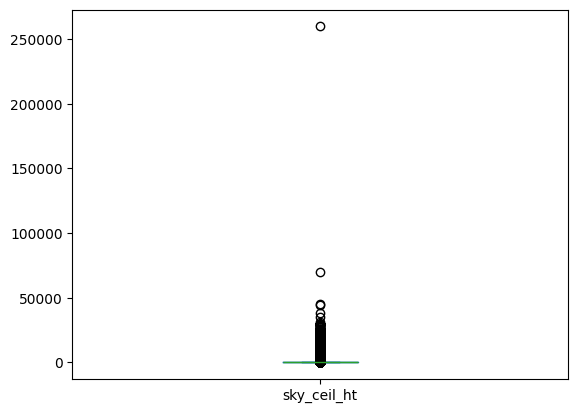

In [204]:
indp_features['sky_ceil_ht'].plot(kind='box')

Checked row counts at several thresholds before picking a cutoff, since ceiling is easy to over-trim: only 2 rows sit above 50,000ft (the `260000` and a `70000`), while values between 25,000 and 50,000 include a real repeated cluster at `30000` (21 occurrences) — a genuine high-altitude reporting convention, not noise. Cutting lower (e.g. at 10,000ft) would have discarded ~1,000 legitimate accidents with ordinary cloud layers. **Cutoff: 50,000ft** — precise enough to remove only the 2 impossible values.

<Axes: >

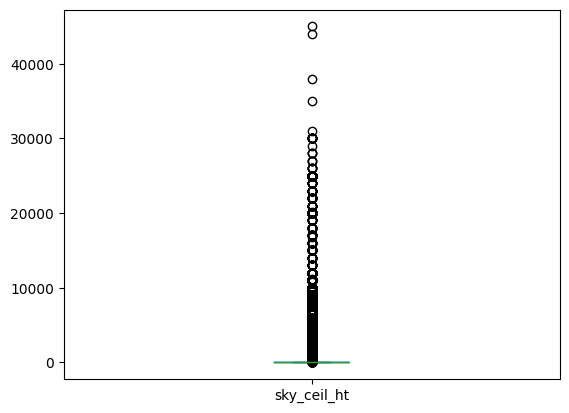

In [205]:
indp_features = indp_features[indp_features['sky_ceil_ht'] < 50000]
indp_features['sky_ceil_ht'].plot(kind='box')

## Outlier check: `gust_kts`

Already established `0.0` is a legitimate "no gust" reading, not missing data. Check the upper tail:

<Axes: >

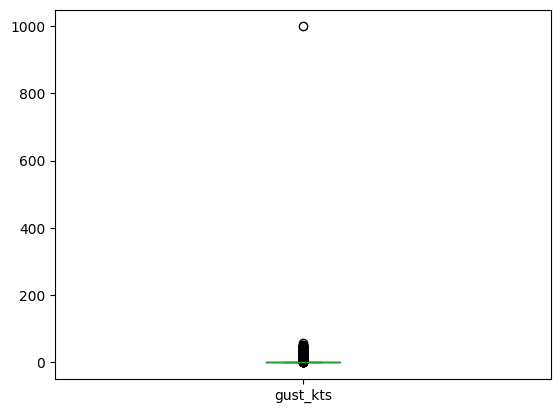

In [206]:
indp_features['gust_kts'].plot(kind='box')

In [207]:
(indp_features['gust_kts'] > 100).sum()

np.int64(1)

Exactly one row at `999.0` — a classic round-number sentinel, not a real gust reading (next real value down is `57.0`). Drop it:

<Axes: >

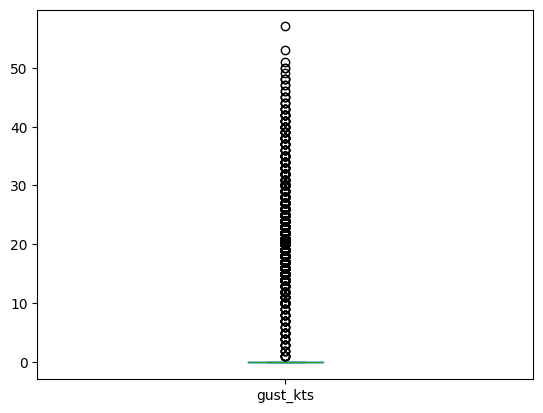

In [208]:
indp_features = indp_features[indp_features['gust_kts'] <= 100]
indp_features['gust_kts'].plot(kind='box')

## Outlier check: `wx_temp`

Likely °F, given the mean/median (~52/63). Check the tail:

<Axes: >

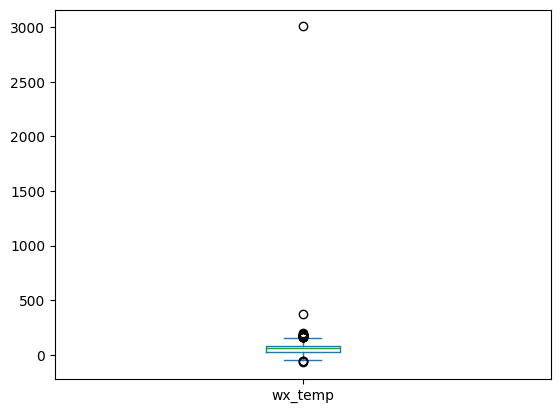

In [209]:
indp_features['wx_temp'].plot(kind='box')

In [210]:
indp_features['wx_temp'].sort_values(ascending=False).head(15)

10688    3006.0
14036     374.0
17843     203.0
9995      190.0
1187      183.0
6652      180.0
8880      180.0
7008      180.0
2947      180.0
6511      178.0
1057      176.0
2761      176.0
3618      172.0
4009      172.0
4943      167.0
Name: wx_temp, dtype: float64

Different pattern than the others: `3006` and `374` are obvious errors, but there's no single clean gap after that — a real cluster of values sits in the 120-190 range with no sharp cliff. Rather than hunting for a gap that isn't there, using a physically-grounded bound instead: the hottest ambient surface temperature ever recorded on Earth is ~134°F (Death Valley, 1913). **Cutoff: 140°F** — removes 34 rows (~0.1% of the data), all physically impossible regardless of what caused the error.

<Axes: >

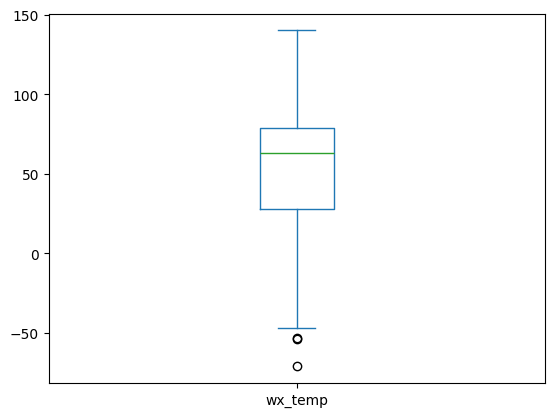

In [211]:
indp_features = indp_features[indp_features['wx_temp'] <= 140]
indp_features['wx_temp'].plot(kind='box')

## `wind_vel_kts` — deliberately not touched

No sentinel pattern here (no suspicious round numbers like `999`/`9999`, no sharp gap in the sorted tail). Extreme values (up to 170kt) are plausible in accident data specifically — severe wind is a realistic causal factor in a crash, not noise. Trimming this column risks throwing away genuine signal, so it's left as-is.

<Axes: >

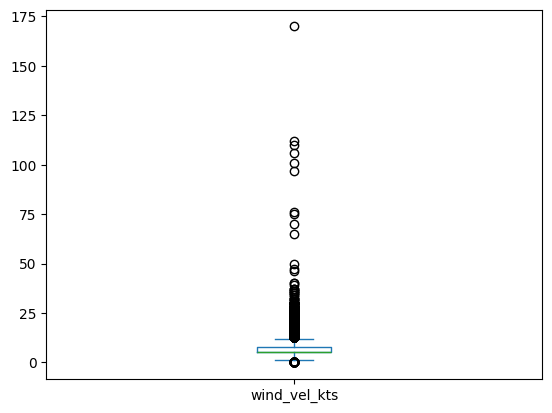

In [212]:
indp_features['wind_vel_kts'].plot(kind='box')

## Result

30,804 → 30,292 rows survived cleaning (removed ~1.7%, all physically implausible values). Next: normalize these features, one-hot encode `wx_cond_basic`, build the `is_fatal` target, and follow the fast.ai lesson 4 linear-model / neural-net-from-scratch pattern.

`is_fatal` update: now that `ev_highest_injury`'s nulls are filled (see above), it's fully equivalent to the original `(inj_tot_f > 0) | (ev_highest_injury == 'FATL')` definition — verified zero mismatches across all 30,804 rows. `fill_injury` already prioritizes `inj_tot_f > 0` internally, so the fill itself baked in that logic. No separate `is_fatal` column needed — `ev_highest_injury == 'FATL'` is now sufficient on its own.

## Encode `wx_cond_basic`

3 categories: VMC (28,788), IMC (1,222), Unk (317).

In [213]:
indp_features['wx_cond_basic'].value_counts()

wx_cond_basic
VMC    28755
IMC     1220
Unk      317
Name: count, dtype: int64

Using `pd.get_dummies` (matches the fast.ai lesson's own approach) rather than sklearn's `OneHotEncoder` — that machinery earns its cost when you need to persist a fitted encoder for new/unseen data later, which isn't the goal for a from-scratch exercise.

`drop_first=True` matters here: one-hot encoding all 3 categories makes them perfectly collinear (any one is fully determined by the other two, since they always sum to 1), which creates a whole undetermined direction in the weight space — you can shift all three dummy weights by any constant and get identical predictions, so gradient descent has nothing to anchor that direction to. Dropping one category (here, `IMC` — alphabetically first) removes the redundant column without losing any information; `IMC` is still fully represented as `Unk=0, VMC=0`.

In [214]:
indp_features = pd.get_dummies(indp_features, columns=['wx_cond_basic'], drop_first=True)
indp_features.head()

,sky_ceil_ht,vis_sm,wind_vel_kts,gust_kts,wx_temp,wx_cond_basic_Unk,wx_cond_basic_VMC
0,0.0,10.0,5.0,0.0,0.0,False,True
1,0.0,10.0,10.0,0.0,57.0,False,True
2,0.0,10.0,15.0,20.0,55.0,False,True
3,0.0,10.0,16.0,0.0,0.0,False,True
4,0.0,10.0,5.0,0.0,19.0,False,True


In [215]:
indp_features.shape

(30292, 7)

Dummy columns come out as `True`/`False` (pandas 2.x default), not `0`/`1` — functionally identical for arithmetic, but cast to numeric explicitly when building the PyTorch tensor later (`torch.tensor(..., dtype=torch.float32)` handles it, or `.astype(float)` beforehand).

## Build the target

`indp_features` lost rows during outlier cleanup (30,804 → 30,292), so the target has to be pulled using the *same surviving index* — not rebuilt from the full `df` — otherwise features and target go out of alignment.

In [216]:
target = (df.loc[indp_features.index, 'ev_highest_injury'] == 'FATL').astype(int)
target.value_counts()

ev_highest_injury
0    24034
1     6258
Name: count, dtype: int64

## Next

Data is ready: 30,292 rows, 7 numeric/dummy features, aligned binary target (20.7% fatal). Next step is yours to write: normalize each numeric column (divide by max or standardize — expect gradient descent to fail without this, same as the fast.ai Titanic notebook), convert `indp_features` and `target` to tensors, then build the linear model — one coefficient vector, `predictions = (X * coeffs).sum(axis=1)`, sigmoid, manual `loss.backward()` + weight update loop. Bring it back once you've got the normalized tensors built and a sample of the values, before writing the training loop.

In [218]:
from torch import tensor
t_dep = tensor(target.values)

In [222]:
import torch
t_indep = tensor(indp_features.astype('float32').values, dtype= torch.float)
t_indep

tensor([[ 0., 10.,  5.,  ...,  0.,  0.,  1.],
        [ 0., 10., 10.,  ..., 57.,  0.,  1.],
        [ 0., 10., 15.,  ..., 55.,  0.,  1.],
        ...,
        [ 0., 10.,  5.,  ...,  0.,  0.,  1.],
        [ 0., 10.,  5.,  ...,  0.,  0.,  1.],
        [ 0., 10.,  5.,  ...,  0.,  0.,  1.]])

In [250]:
n_coeff = t_indep.shape[1]
coeffs = torch.rand(n_coeff).requires_grad_()
coeffs

tensor([0.8146, 0.1254, 0.6260, 0.8314, 0.5308, 0.7647, 0.0763],
       requires_grad=True)

In [251]:
coeffs * t_indep

tensor([[0.0000, 0.0836, 0.0184,  ..., 0.0000, 0.0000, 0.0763],
        [0.0000, 0.0836, 0.0368,  ..., 0.2161, 0.0000, 0.0763],
        [0.0000, 0.0836, 0.0552,  ..., 0.2085, 0.0000, 0.0763],
        ...,
        [0.0000, 0.0836, 0.0184,  ..., 0.0000, 0.0000, 0.0763],
        [0.0000, 0.0836, 0.0184,  ..., 0.0000, 0.0000, 0.0763],
        [0.0000, 0.0836, 0.0184,  ..., 0.0000, 0.0000, 0.0763]],
       grad_fn=<MulBackward0>)

In [252]:
vals, indices = t_indep.max(dim=0)
t_indep = t_indep/vals

In [253]:
preds = (coeffs * t_indep).sum(1)

In [254]:
preds[:10]

tensor([0.1782, 0.4128, 0.7153, 0.2188, 0.2503, 0.3602, 0.3224, 0.6965, 0.4845,
        0.5515], grad_fn=<SliceBackward0>)

In [255]:
loss = torch.abs(preds - t_dep).mean()
loss

tensor(0.4833, grad_fn=<MeanBackward0>)

In [256]:
def calc_preds(coeffs, indeps): return (indeps*coeffs).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return torch.abs(calc_preds(coeffs, indeps)-deps).mean()


In [257]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 0.1)
    coeffs.grad.zero_()
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.4268)


In [258]:
def update_coeffs(coeffs,lr):
    coeffs.sub_(coeffs.grad * lr)
    coeffs.grad.zero_()

In [267]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, t_indep, t_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

In [268]:
def init_coeffs(): return (torch.rand(n_coeff)-0.5).requires_grad_()


In [269]:
def train_model(epochs=30, lr=0.01):
    torch.manual_seed(442)
    coeffs = init_coeffs()
    for i in range(epochs): one_epoch(coeffs, lr=lr)
    return coeffs

In [270]:
coeffs = train_model(18, lr=0.2)

0.482; 0.374; 0.278; 0.286; 0.298; 0.281; 0.297; 0.278; 0.298; 0.275; 0.298; 0.271; 0.298; 0.268; 0.300; 0.262; 0.299; 0.260; 

## Postmortem: why this model doesn't work

Two things compound here, and either one alone would be enough to sink this model.

**1. No sigmoid on the output.** `preds = (coeffs * t_indep).sum(1)` is a raw linear combination — nothing constrains it to `[0, 1]`. But `t_dep` is strictly `0` or `1`. After training, `preds` lands around `[-0.37, 0.32]` — never anywhere near a confident "1" for a fatal accident, and sometimes negative, which isn't a meaningful prediction for a binary target at all.

**2. L1 (MAE) loss has no braking mechanism.** `d|pred-target|/d(pred) = sign(pred-target)` — always exactly ±1, no matter whether the miss is by 0.01 or by 5. Contrast with MSE: `d(pred-target)^2/d(pred) = 2(pred-target)`, which shrinks toward zero as the prediction approaches the target. That shrinking is what lets gradient descent decelerate and settle into a minimum. L1's gradient never decelerates, so a fixed-size update step (`lr * grad`) keeps overshooting once it's near a solution.

**Evidence this is a real structural problem, not "just needs more epochs":**
- Naive baseline (always predict "not fatal") gets L1 loss = 0.2066 (the base fatal rate).
- This trained model's loss oscillates between ~0.24 and ~0.32 across 18 epochs at lr=0.2 — *worse than doing nothing*, the entire time.
- lr=0.02: loss decreases smoothly (0.397 -> 0.261) but hasn't converged within 18 epochs.
- lr=0.002: too slow to tell anything (0.397 -> 0.378).

So this isn't a tuning problem in isolation — it's a wrong-loss-for-this-architecture problem. A raw linear model with no sigmoid, trained on MAE, has no way to (a) express confidence near 0 or 1, or (b) settle into a minimum instead of oscillating around one.

**Next step:** add a sigmoid to bound `preds` to `[0,1]`, and switch to binary cross-entropy loss, whose gradient shrinks as predictions approach the true label (and grows when confidently wrong) — that addresses both problems above.
